In [1]:
# Import all necessary Libararies

import pandas as pd
import numpy as np
import string 
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [2]:
df = pd.read_csv('Cyber Dataset.csv',encoding='latin1')
df.head()

,Comments,Classes
0,Tu bohot bekar aadmi hai.,A
1,Aap ki baat bilkul sahi hai.,NaN
2,Chal nikal yahan se bewakoof!,A
3,Yeh movie bohot achi thi.,NaN
4,Tera dimagh kharab hai kya?,A


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5164 entries, 0 to 5163
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Comments  5164 non-null   object
 1   Classes   2508 non-null   object
dtypes: object(2)
memory usage: 80.8+ KB


In [4]:
df.isna().sum()

Comments       0
Classes     2656
dtype: int64

## Handle Missing Values and Clean Text

In [5]:
# Fill all NaN values with 0 (no abuse)

df['label'] = df['Classes'].apply(lambda x: 1 if x == 'A' else 0)

# Corrected cleaning function with proper indentation
def clean_roman_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase first (helps with matching)
    text = text.lower()
    
    # Keep only letters and spaces (removes punctuation, emojis, and special chars)
    text = re.sub(r'[^a-z\s]', '', text) 
    
    # Join split words to strip extra whitespaces
    return " ".join(text.split())

# Apply the corrected function
df['clean_comment'] = df['Comments'].apply(clean_roman_text)

# Let's inspect 3 rows to confirm we actually have text in 'clean_comment' now!
print(df[['Comments', 'clean_comment', 'label']].head(3))


                        Comments                 clean_comment  label
0      Tu bohot bekar aadmi hai.      tu bohot bekar aadmi hai      1
1   Aap ki baat bilkul sahi hai.   aap ki baat bilkul sahi hai      0
2  Chal nikal yahan se bewakoof!  chal nikal yahan se bewakoof      1


## Initialize TF-IDF Vectorizer

In [6]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_comment'].astype('U'))
y = df['label']

In [7]:
# Split data into text and train
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# initialize the 3 models
models = {
    "Naive_bayes" : MultinomialNB(),
    "SVM" : SVC(kernel='linear',probability=True,random_state=42),
    "Random_Forest" : RandomForestClassifier(n_estimators =100,random_state=42)
}
for name, model in models.items():
    print(f"\n---Training {name}---")
    model.fit(X_train,y_train)


---Training Naive_bayes---

---Training SVM---

---Training Random_Forest---


In [8]:
# Evaluation
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,predictions):.4f}")
print(classification_report(y_test,predictions))

Accuracy: 0.8006
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       543
           1       0.83      0.73      0.78       490

    accuracy                           0.80      1033
   macro avg       0.80      0.80      0.80      1033
weighted avg       0.80      0.80      0.80      1033



In [9]:
import pickle

# 1. Save the Vectorizer
try:
    with open('tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(vectorizer, f)
    print("Saved: tfidf_vectorizer.pkl")
except NameError:
    print("Error: 'vectorizer' variable is not defined. Please run your TF-IDF cell again.")

# 2. Automatically save whatever models exist in your dictionary
if 'models' in locals() or 'models' in globals():
    print("\nDetecting models in your dictionary...")
    for model_name, model_object in models.items():
        # This dynamically creates file names like 'Naive_Bayes_model.pkl' or 'SVM_model.pkl'
        file_name = f"{model_name}_model.pkl"
        with open(file_name, 'wb') as f:
            pickle.dump(model_object, f)
        print(f"Successfully saved: {file_name}")
else:
    print("Error: The 'models' dictionary was not found. Please run your training loop cell again.")

Saved: tfidf_vectorizer.pkl

Detecting models in your dictionary...
Successfully saved: Naive_bayes_model.pkl
Successfully saved: SVM_model.pkl
Successfully saved: Random_Forest_model.pkl


C:\Users\me\AppData\Local\Temp\ipykernel_12104\1847034453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="viridis")


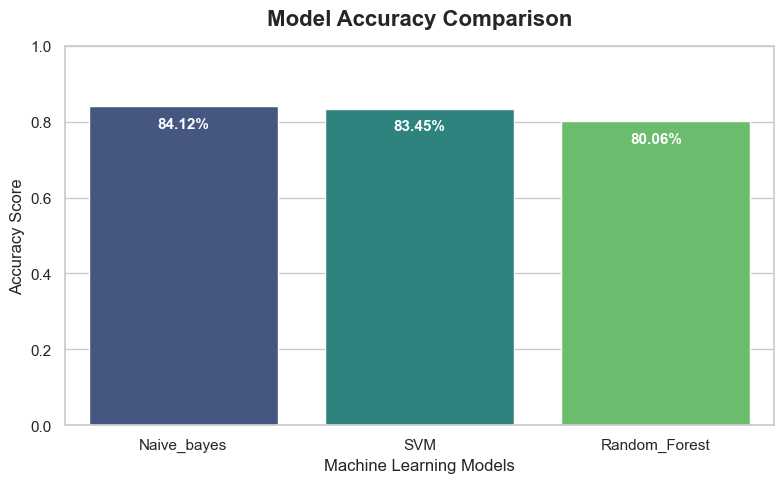

In [10]:
# 1. Calculate accuracy for each model
accuracies = {}
for name, model in models.items():
    preds = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, preds)

# 2. Plot the accuracies
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Create a bar plot
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="viridis")

# Add title and labels
plt.title("Model Accuracy Comparison", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 1.0) # Set limit from 0 to 100%

# Add text labels on top of the bars showing the exact percentage
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() - 0.08), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

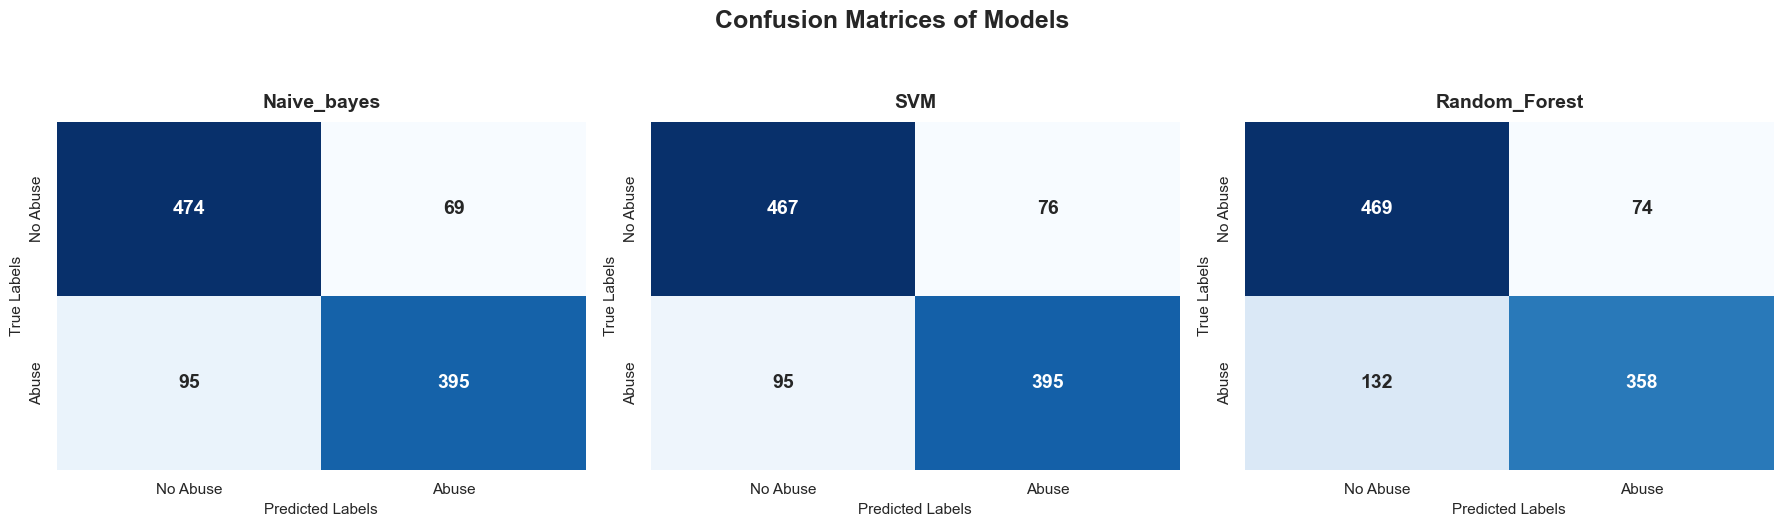

In [11]:
# Create a 1-row, 3-column layout for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices of Models", fontsize=18, fontweight='bold', y=1.05)

# Labels for the matrix boxes
class_labels = ["No Abuse", "Abuse"]

for idx, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    
    # Plot using Seaborn's heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels,
                annot_kws={"size": 14, "weight": "bold"})
    
    axes[idx].set_title(f"{name}", fontsize=14, fontweight='bold', pad=10)
    axes[idx].set_xlabel("Predicted Labels", fontsize=11)
    axes[idx].set_ylabel("True Labels", fontsize=11)

plt.tight_layout()
plt.show()